In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('perrin-freres-monthly-champagne-.csv')
df

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0
...,...,...
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0
105,NaN,NaN


In [4]:
df.shape

(107, 2)

In [5]:
df.isna().sum()

Month                                                     1
Perrin Freres monthly champagne sales millions ?64-?72    2
dtype: int64

In [6]:
df.drop([105,106],axis=0,inplace = True)

In [7]:
df.shape

(105, 2)

In [9]:
df.isna().sum()

Month                                                     0
Perrin Freres monthly champagne sales millions ?64-?72    0
dtype: int64

In [11]:
df.dtypes

Month                                                      object
Perrin Freres monthly champagne sales millions ?64-?72    float64
dtype: object

In [12]:
import datetime

In [13]:
df['Month'] = pd.to_datetime(df['Month'])

In [14]:
df.dtypes

Month                                                     datetime64[ns]
Perrin Freres monthly champagne sales millions ?64-?72           float64
dtype: object

In [15]:
df['Month']

0     1964-01-01
1     1964-02-01
2     1964-03-01
3     1964-04-01
4     1964-05-01
         ...    
100   1972-05-01
101   1972-06-01
102   1972-07-01
103   1972-08-01
104   1972-09-01
Name: Month, Length: 105, dtype: datetime64[ns]

In [17]:
df = df.rename(columns={'Perrin Freres monthly champagne sales millions ?64-?72':'Monthly Sales'})

In [19]:
df.head(1)

,Month,Monthly Sales
0,1964-01-01,2815.0


In [16]:
import matplotlib.pyplot as plt

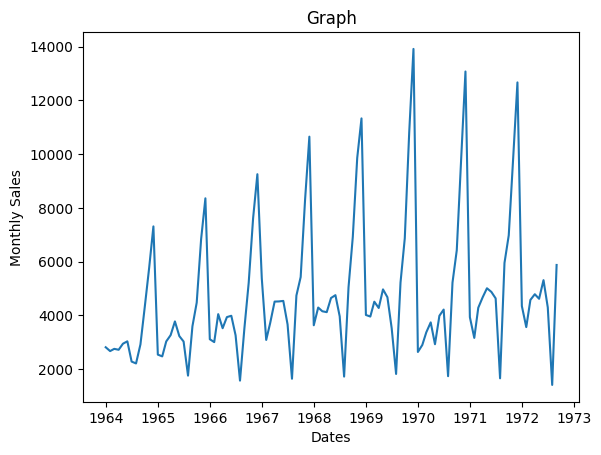

<Figure size 640x480 with 0 Axes>

In [22]:
plt.plot(df['Month'],df['Monthly Sales'])
plt.xlabel('Dates')
plt.ylabel('Monthly Sales')
plt.title('Graph')
plt.show()
plt.gcf().autofmt_xdate()

Check if data is stationary

In [23]:
from statsmodels.tsa.stattools import adfuller

In [24]:
test_results = df['Monthly Sales']

In [25]:
#H0 : it is not stationary
#H1: it is stationary
def adfuller_test(monthlysales):
    result = adfuller(monthlysales)
    labels = ['ADF TEST STATSTIC','P-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(f'{label}: {value}')
        
    if result[1] <= 0.05:
        print("Reject the null hypothesis")
    else:
        print("Fail to reject the null hypothesis")

In [26]:
adfuller_test(df['Monthly Sales'])

ADF TEST STATSTIC: -1.833593056327616
P-value: 0.3639157716602485
#Lags Used: 11
Number of Observations Used: 93
Fail to reject the null hypothesis


In [27]:
df['Sales First diffrence'] = df['Monthly Sales'] - df['Monthly Sales'].shift(1)

In [28]:
df['Seasonal First Diffrence '] = df['Monthly Sales'] - df['Monthly Sales'].shift(12)

In [36]:
df['Monthly Sales'].shift(12)

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
        ...  
100    5010.0
101    4874.0
102    4633.0
103    1659.0
104    5951.0
Name: Monthly Sales, Length: 105, dtype: float64

In [29]:
df.head(10)

,Month,Monthly Sales,Sales First diffrence,Seasonal First Diffrence
0,1964-01-01,2815.0,NaN,NaN
1,1964-02-01,2672.0,-143.0,NaN
2,1964-03-01,2755.0,83.0,NaN
3,1964-04-01,2721.0,-34.0,NaN
4,1964-05-01,2946.0,225.0,NaN
5,1964-06-01,3036.0,90.0,NaN
6,1964-07-01,2282.0,-754.0,NaN
7,1964-08-01,2212.0,-70.0,NaN
8,1964-09-01,2922.0,710.0,NaN
9,1964-10-01,4301.0,1379.0,NaN


In [30]:
adfuller_test(df['Seasonal First Diffrence '].dropna())

ADF TEST STATSTIC: -7.626619157213164
P-value: 2.060579696813685e-11
#Lags Used: 0
Number of Observations Used: 92
Reject the null hypothesis


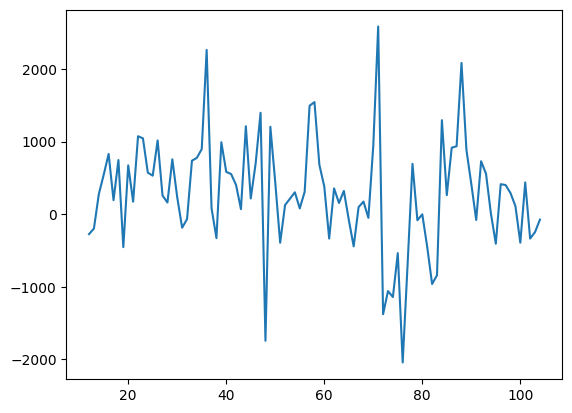

In [34]:
plt.plot(df['Seasonal First Diffrence '])

In [38]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

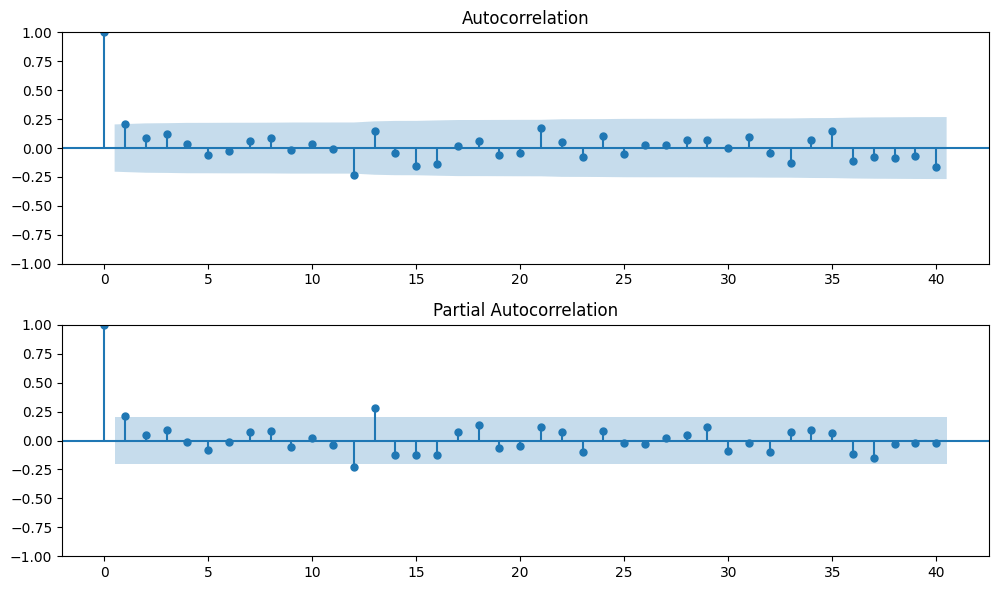

In [42]:
import statsmodels.api as sm
fig = plt.figure(figsize=(10,6))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Seasonal First Diffrence '].iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Seasonal First Diffrence '].iloc[13:],lags=40,ax=ax2)
plt.tight_layout()
plt.show()

In [44]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(df['Monthly Sales'],order = (1,1,1))
model_fit = model.fit()

In [45]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          Monthly Sales   No. Observations:                  105
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -952.814
Date:                Fri, 25 Oct 2024   AIC                           1911.627
Time:                        18:33:44   BIC                           1919.560
Sample:                             0   HQIC                          1914.841
                                - 105                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4545      0.114      3.999      0.000       0.232       0.677
ma.L1         -0.9666      0.056    -17.316      0.000      -1.076      -0.857
sigma2      5.226e+06   6.17e+05      8.473      0.000    4.02e+06    6.43e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.91   Jarque-Bera (JB):                 2.59
Prob(Q):                              0.34   Prob(JB):                         0.27
Heteroskedasticity (H):               3.40   Skew:                             0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: >

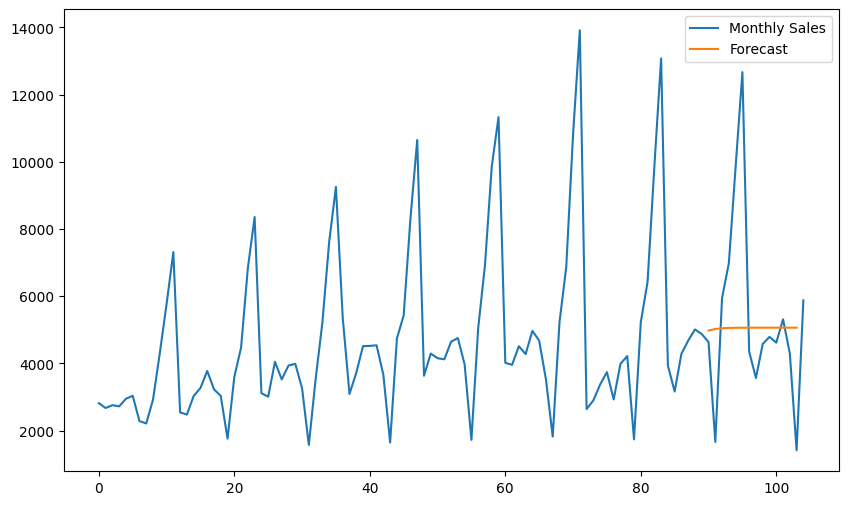

In [46]:
df['Forecast'] = model_fit.predict(start=90,end=103,dynamic=True)
df[['Monthly Sales','Forecast']].plot(figsize=(10,6))

In [47]:
import statsmodels.api as sm

In [49]:
model = sm.tsa.statespace.SARIMAX(df['Monthly Sales'],order=(1,1,1),seasonal_order=(1,1,1,12))
results = model.fit()


 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.07295D+00    |proj g|=  4.80911D-02

At iterate    5    f=  7.04942D+00    |proj g|=  1.53381D-02

At iterate   10    f=  7.04713D+00    |proj g|=  2.99462D-04

At iterate   15    f=  7.04708D+00    |proj g|=  5.05903D-03

At iterate   20    f=  7.04413D+00    |proj g|=  1.18416D-02

At iterate   25    f=  7.03252D+00    |proj g|=  1.06179D-03

At iterate   30    f=  7.03240D+00    |proj g|=  5.69966D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nac

<Axes: >

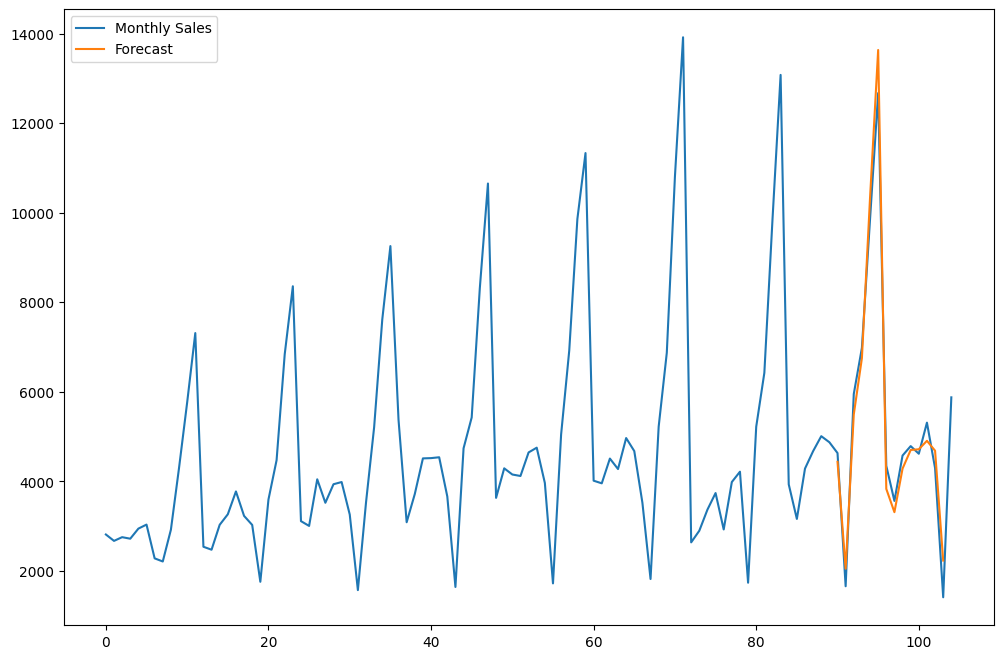

In [50]:
df['Forecast'] = results.predict(start=90,end=103,dynamic=True)
df[['Monthly Sales','Forecast']].plot(figsize=(12,8))

In [53]:
df.index = pd.to_datetime(df.index)

In [54]:
from pandas.tseries.offsets import DateOffset
future_dates = [df.index[-1] + DateOffset(months=x)for x in range(0,24)]

/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_1831/557542608.py:2: UserWarning: Discarding nonzero nanoseconds in conversion.
  future_dates = [df.index[-1] + DateOffset(months=x)for x in range(0,24)]


In [55]:
future_datest_df=pd.DataFrame(index=future_dates[1:],columns=df.columns)

In [56]:
future_datest_df.tail()

,Month,Monthly Sales,Sales First diffrence,Seasonal First Diffrence,Forecast
1971-08-01 00:00:00.000000104,NaN,NaN,NaN,NaN,NaN
1971-09-01 00:00:00.000000104,NaN,NaN,NaN,NaN,NaN
1971-10-01 00:00:00.000000104,NaN,NaN,NaN,NaN,NaN
1971-11-01 00:00:00.000000104,NaN,NaN,NaN,NaN,NaN
1971-12-01 00:00:00.000000104,NaN,NaN,NaN,NaN,NaN


In [57]:

future_df=pd.concat([df,future_datest_df])

/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_1831/3298648333.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  future_df=pd.concat([df,future_datest_df])


<Axes: >

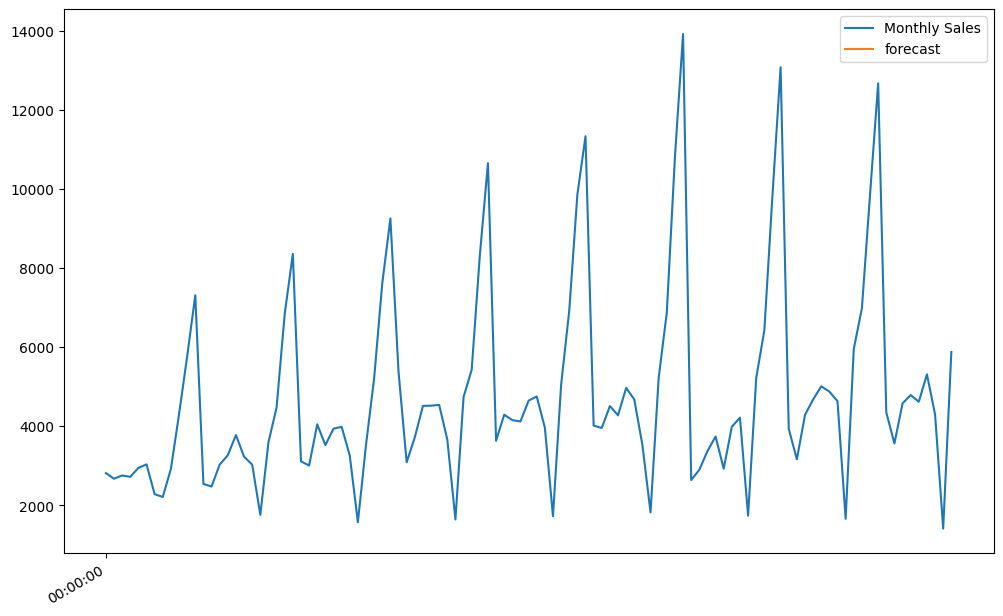

In [59]:
future_df['forecast'] = results.predict(start = 104, end = 120, dynamic= True)  
future_df[['Monthly Sales', 'forecast']].plot(figsize=(12, 8)) 